# INTERPOLATIONS 




## DIVIDED DIFFERENCE 

In [ ]:

def divided_differences(nodes, values):
    ### input: list of nodes [x0, x1, ..., xn] length n+1 & list of values [f(x0), f(x1), ..., f(xn)] length n+1
    ### Output: list of divided differences [f[x0], f[x0, x1], ..., f[x0, x1, ..., xn]] length n+1
    dd = values.copy()

    result = [dd[0]]

    for k in range(1, len(nodes)):
        for i in range(len(nodes) - k):
            dd[i] = (dd[i + 1] - dd[i]) / (nodes[i + k] - nodes[i])

        result.append(dd[0])

    return result

    

## LAGRANGE INTERPOLATION 

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
def lagrange_interpolation(x_values: list, y_values: list, x: int):
    """
    Computes the Lagrange interpolation polynomial at the point x.

    x_values: list of interpolation nodes, e.g. [0, 1, 2]
    y_values: list of function values, e.g. [1, 3, 2]
    x: the point where we want to evaluate the polynomial
    """
    n = len(x_values)
    result = 0

    for i in range(n):
        # Start computing L_i(x)
        L_i = 1

        for j in range(n):
            if j != i:
                L_i = L_i * (x - x_values[j]) / (x_values[i] - x_values[j])

        # Add y_i * L_i(x) to the result
        result = result + y_values[i] * L_i

    return result


# Original function from the exercise
def f(x):
    return np.sin(x)   # change this, e.g. np.exp(x), 1/(1+x**2), ...

# Interval
a = 0
b = 2*np.pi

# n values: 2^i
n_list = [2**i for i in range(1, 7)]   # 2, 4, 8, 16, 32, 64

# Fine grid for smooth plotting
x_plot = np.linspace(a, b, 1000)
y_true = f(x_plot)

# Plot original function
plt.figure(figsize=(10, 6))
plt.plot(x_plot, y_true, label="Original function f(x)", linewidth=3)

# Plot interpolation for each n
for n in n_list:
    # interpolation nodes
    x_values = np.linspace(a, b, n)
    y_values = f(x_values)

    # evaluate Lagrange interpolation at many points
    y_interp = []
    for x in x_plot:
        y_interp.append(lagrange_interpolation(x_values, y_values, x))

    plt.plot(x_plot, y_interp, label=f"Lagrange interpolation, n={n}")

# Plot settings
plt.xlabel("x")
plt.ylabel("y")
plt.title("Lagrange interpolation for n = 2^i")
plt.legend()
plt.grid(True)
plt.show()

## NEWTON INTERPOLATION 

In [ ]:
def newton_coefficients(x_values, y_values):
    """
    Computes the Newton divided difference coefficients.

    x_values: interpolation nodes
    y_values: function values

    returns: list of Newton coefficients
    """

    n = len(x_values)

    # Start with a copy of y_values
    coefficients = y_values.copy()

    # Compute divided differences
    for k in range(1, n):
        for i in range(n - 1, k - 1, -1):
            numerator = coefficients[i] - coefficients[i - 1]
            denominator = x_values[i] - x_values[i - k]
            coefficients[i] = numerator / denominator

    return coefficients

def newton_interpolation(x_values, y_values, x):
    """
    Evaluates the Newton interpolation polynomial at x.
    """

    coefficients = newton_coefficients(x_values, y_values)

    n = len(x_values)

    # Start with the highest coefficient
    result = coefficients[n - 1]

    # Nested multiplication
    for i in range(n - 2, -1, -1):
        result = result * (x - x_values[i]) + coefficients[i]

    return result

## NEVILLE INTERPOLATION (extention of newton)

In [21]:
def neville_interpolation(x_values, y_values, x):
    """
    Evaluates the interpolation polynomial at x using Neville's algorithm.
    """

    n = len(x_values)

    # Start with the y-values
    p = y_values.copy()

    # Build Neville table in-place
    for k in range(1, n):
        for i in range(n - k):
            left = (x_values[i + k] - x) * p[i]
            right = (x - x_values[i]) * p[i + 1]
            denominator = x_values[i + k] - x_values[i]

            p[i] = (left + right) / denominator

    return p[0]
print(neville_interpolation([0, 1,2,3 ], [ 0, 1,8, 27], 1.5))

3.375


## HERMITE INTERPOLATION 


In [ ]:
import numpy as np 
import matplotlib.pyplot as plt

def f(x): #our function 
    return np.sin(x)

def df(x): #our derivative 
    return np.cos(x)

def lagrange_basis(k, x_grid, x):
    """
    Computes the k-th Lagrange basis polynomial l_k(x).
    """
    result = 1.0

    for j in range(len(x_grid)):
        if j != k:
            result *= (x - x_grid[j]) / (x_grid[k] - x_grid[j])

    return result

def lagrange_basis_derivative_at_node(k, x_grid):
    """
    Computes l_i'(x_i).
    Formula: l_i'(x_k) = sum_{j != i} 1 / (x_i - x_j)
    """
    result = 0.0

    for j in range(len(x_grid)):
        if j != k:
            result += 1 / (x_grid[k] - x_grid[j])

    return result


def HermiteInterpolationFormula(x_grid, y_grid, dy_grid, x_eval):
    """
    Inputs:
        x_grid  = interpolation nodes x_k
        y_grid  = function values f(x_k)
        dy_grid = derivative values f'(x_k)
        x_eval  = points where we evaluate the Hermite polynomial
    """

    hermite_values = []

    for x in x_eval:
        H = 0.0

        for k in range(len(x_grid)):
            x_k = x_grid[k]

            # Lagrange basis l_k(x)
            l_k = lagrange_basis(k, x_grid, x)

            # Derivative l_k'(x_k)
            dl_k = lagrange_basis_derivative_at_node(k, x_grid)

            # Hermite basis functions
            A = (1 - 2 * (x - x_k) * dl_k) * l_k**2
            B = (x - x_k) * l_k**2

            # Add contribution from f(x_k) and f'(x_k)
            H += y_grid[k] * A + dy_grid[k] * B

        hermite_values.append(H)

    return np.array(hermite_values)


#PLOTTING 
a = 0
b = np.pi

n = 4

x_grid = np.linspace(a, b, n + 1)
y_grid = f(x_grid)
dy_grid = df(x_grid)

x_eval = np.linspace(a, b, 1000)
y_true_values = f(x_eval)

hermite_values = HermiteInterpolationFormula(x_grid, y_grid, dy_grid, x_eval)

plt.figure(figsize=(8, 6))
plt.plot(x_eval, y_true_values, label="Original function")
plt.plot(x_eval, hermite_values, label="Hermite interpolation")
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"Hermite interpolation of $f(x)=\sin(x)$")
plt.legend()
plt.show()

## ERROR CONVERGENCE RATE/SPEED (Lagrange, Newton, Nevilles)

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt
a = 0
b = 1

n_list = [2, 4, 8, 12, 16, 20]
x_eval = np.linspace(a, b, 1000)
y_true_values = f(x_eval) #the function with x 

errors_list = []

plt.figure(figsize=(8, 6))

for n in n_list:
    x_grid = np.linspace(a, b, n + 1)
    y_grid = f(x_grid)

    lagrange_values = LagrangeInterpolation(x_grid, y_grid, x_eval) #SAME FOR NEWTON AND NEVILLE 

    error = np.max(np.abs(y_true_values - lagrange_values))
    errors_list.append(error)

    plt.plot(x_eval, lagrange_values, label=f"n={n}")

plt.xlabel("x")
plt.ylabel("y")
plt.title(r"Lagrange interpolation of $f(x)=x^{1/4}$ on $[0,1]$")
plt.legend()
plt.show()


errors_array = np.array(errors_list)
n_array = np.array(n_list)

plt.figure(figsize=(8, 6))
plt.loglog(n_array, errors_array, "o-", label="Interpolation error")
plt.xlabel("n")
plt.ylabel("Maximum error")
plt.title("Log-log plot of Lagrange interpolation error")
plt.legend()
plt.show()

## SPLINES INTERPOLATION  

### LINEAR SPLINES (+linear convergence rate)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np



#### Question 1e
a = 0
b = 1
power = range(2, 11)
n_list = [2**k for k in power]

x_eval = np.linspace(a, b, 10001)
y_true_values = x_eval**(1/4)

def LinearSplines(set_ordered_gridpoints, values_at_gridpoints, set_evaluationpoints):
    x_grid = set_ordered_gridpoints
    y_grid = values_at_gridpoints
    x_eval = set_evaluationpoints
    splinevalues = []

    for x in x_eval:
        if x <= x_grid[0]:
            i = 0
        elif x >= x_grid[-1]:
            i = len(x_grid) - 2
        else:
            i = 0
            for j in range(len(x_grid) - 1):
                if x_grid[j] <= x <= x_grid[j + 1]:
                    i = j
                    break

        x_left, x_right = x_grid[i], x_grid[i+1]
        y_left, y_right = y_grid[i], y_grid[i+1]

        b_left = (x_right - x) / (x_right - x_left)
        b_right = (x - x_left) / (x_right - x_left)

        y_interpolated = y_left * b_left + y_right * b_right
        splinevalues.append(y_interpolated)

    return np.array(splinevalues)

plt.figure(figsize=(12, 8))
plt.plot(x_eval, y_true_values, label=r'$f(x)=x^{1/4}$', linewidth=2)

errors_list = []

for n in n_list:
    x_grid = np.linspace(a, b, n + 1)
    y_grid = x_grid**(1/4)

    linear_values = LinearSplines(x_grid, y_grid, x_eval)
    error = np.max(np.abs(y_true_values - linear_values))

    errors_list.append(error)

    plt.plot(x_eval, linear_values, label=f'n={n}')

plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear spline interpolation of $f(x)=x^{1/4}$ on [0,1]")
plt.legend()
plt.show()

errors_array = np.array(errors_list)
reference = errors_array[-1] * (np.array(n_list) / n_list[-1])**(-1/4)

plt.figure(figsize=(8, 6))
plt.loglog(n_list, errors_array, label='Interpolation error')
plt.loglog(n_list, reference, label=r'Reference slope $n^{-1/4}$')
plt.xlabel('n')
plt.ylabel('Maximum error')
plt.title('Log-log plot of interpolation error')
plt.legend()
plt.show()

print("Convegrence speed of the errors is algebraic with m= 1/4")


## PIECEWIESE CONSTANT SPLINE APPROXIMATION 

In [ ]:
def piecewise_constant_approximation(set_ordered_gridpoints, set_evaluationpoints ):
    x_grid = set_ordered_gridpoints #nodes
    x_eval = set_evaluationpoints #evaluation points 
    approximation=[]
    
     # x_grid looks like [x0, x1, ... x{n-1}]
    for x in x_eval: #go through every values of x we want to interpolate
        if x <= x_grid[0]:  # if x is smaller or equal to the 1st grid point
            i = 0           #interval index is 0, we use the 1st interval [x_grid[0], x_grid[1]]
        elif x >= x_grid[-1]:  # if x is greater or equal to the last grid point
            i = len(x_grid) - 2 #since indeces are from 0 to n-1 the last interval is [x_{n-2}, x_{n-1}] 
        else: #now points inside of the domain 
            i = 0 #will be overwritten 
            for j in range(len(x_grid) - 1): 
                if x_grid[j] <= x <= x_grid[j + 1]: #check if x is inside
                    i = j #gives the index for the interval 
                    break
        x_left, x_right= x_grid[i], x_grid[i+1] #interval where x lies 
        y_interpolated= (4/3)*((x_right**(3/4) - x_left**(3/4))/(x_right-x_left)) #OVERALL CELL AVERAGE (comes from integral over the interval)
        approximation.append(y_interpolated)
        
    return approximation  

#PLOT 
f_opt= piecewise_constant_approximation(x_grid, x_eval)


plt.figure(figsize=(12, 8))
plt.plot(x_eval, y_true_values, label=r"$f(x)=x^{-1/4}$")
plt.step(x_eval, f_opt, label=r"$f_{\mathrm{opt}}$")

plt.xlabel("x grid ")
plt.ylabel("y grid")
plt.title(" f_optimal")
plt.legend()
plt.show()


# DIFFERENTIATION 


##  GENERAL CASE 

In [ ]:
def divided_differences_coefficients(x_nodes, y_nodes):
    """
    Computes Newton divided difference coefficients.
    """


    x_nodes = np.array(x_nodes, dtype=float)
    coeffs = np.array(y_nodes, dtype=float)

    n = len(x_nodes)

    for level in range(1, n):
        for i in range(n - 1, level - 1, -1):
            coeffs[i] = (coeffs[i] - coeffs[i - 1]) / (x_nodes[i] - x_nodes[i - level])

    return coeffs

def general_derivative_approximation(f, x_nodes):
    """
    Approximates f'(x0), where x0 = x_nodes[0]
    Uses the general formula from Theorem 2.17.
    """

    x_nodes = np.array(x_nodes, dtype=float)
    y_nodes = f(x_nodes)

    coeffs = divided_differences_coefficients(x_nodes, y_nodes)

    x0 = x_nodes[0]

    derivative_approx = 0.0

    product = 1.0

    for k in range(1, len(x_nodes)):
        derivative_approx += product * coeffs[k]

        # Update product:
        # after k=1, product becomes (x0 - x1)
        # after k=2, product becomes (x0 - x1)(x0 - x2)
        product *= (x0 - x_nodes[k])

    return derivative_approx

## FORWARD DIFFERENCE 

In [ ]:
def forward_difference(f, x0, h):

    return (f(x0 + h) - f(x0)) / h

## SYMMETRIC/CENTRAL DIFFERENCE 
used when x0 is an interior point: x-1 and x1 exist 

In [ ]:
def central_difference(f, x0, h):

    return (f(x0 + h) - f(x0 - h)) / (2 * h)

## ONE SIDED FORWARD DIFFERENCE 
used with 3 points when x0 is at the left boundary 

In [ ]:
def forward_difference_3point(f, x0, h):
    
    return (-3 * f(x0) + 4 * f(x0 + h) - f(x0 + 2*h)) / (2 * h)

## ERRORS CONVERGENCE 

In [ ]:
import matplotlib.pyplot as plt

def derivative_error_convergence(f, df, x0, h_list):
    errors_forward = []
    errors_central = []
    errors_forward_3point = []

    true_value = df(x0)

    for h in h_list:
        approx_forward = forward_difference(f, x0, h)
        approx_central = central_difference(f, x0, h)
        approx_forward_3point = forward_difference_3point(f, x0, h)

        errors_forward.append(abs(true_value - approx_forward))
        errors_central.append(abs(true_value - approx_central))
        errors_forward_3point.append(abs(true_value - approx_forward_3point))

    return np.array(errors_forward), np.array(errors_central), np.array(errors_forward_3point)

plt.figure(figsize=(8, 6))
plt.loglog(h_list, errors_forward, "o-", label="Forward difference")
plt.loglog(h_list, errors_central, "o-", label="Central difference")
plt.loglog(h_list, errors_forward_3point, "o-", label="3-point forward difference")
plt.xlabel("h")
plt.ylabel("Absolute error")
plt.title("Error convergence of finite difference formulas")
plt.legend()
plt.show()

# INTEGRATION 

## MIDPOINT + error 

In [ ]:
def any_function(f, x):
    return f(x)
f=lambda x: x**(1/4)


def composite_midpoint(a, b, f, n):
    sum=0
    eval_points=np.linspace(a, b, n+1)
    for i in range(len(eval_points)-1):
        mid_points= (eval_points[i+1]+eval_points[i])/2
        value= any_function(f, mid_points)
        sum+=value*((b-a)/n)
    return  sum

def error_midpoint(a, b, f, n, exact_value):
    approx = composite_midpoint(a, b, f, n)
    return abs(approx - exact_value)
for n in [2**1, 2**2, 2**3, 2**4, 2**5, 2**6, 2**7, 2**8, 2**9, 2**10]:
    print(n, error_midpoint(0, 1, f, n, 0.8))

## TRAPEZOID + error 

In [ ]:
def any_function(f, x):
    return f(x)
f=lambda x: x**(1/4)

def composite_trapezoid(a, b, f, n):
    sum=0
    eval_points=np.linspace(a, b, n+1)
    for i in range(len(eval_points)-1):
        mid_values= (any_function(f, eval_points[i+1])+any_function(f, eval_points[i]))/2
        sum+=mid_values*((b-a)/n)
    return  sum


def error_trapezoid(a, b, f, n, exact_value):
    approx = composite_trapezoid(a, b, f, n)
    return abs(approx - exact_value)
for n in [2**1, 2**2, 2**3, 2**4, 2**5, 2**6, 2**7, 2**8, 2**9, 2**10]:
    print(n, error_trapezoid(0, 1, f, n, 0.8))

## SIMPSONS FORMULA + error 

In [ ]:
def any_function(f, x):
    return f(x)
f=lambda x: x**(1/4)

def composite_simpsons(a, b, f, n):
    sum=0
    eval_points=np.linspace(a, b, n+1)
    for i in range(n//2):
        sumvalues= (any_function(f, eval_points[2*i])+4*any_function(f, eval_points[2*i+1]) +any_function(f, eval_points[2*i+2]))/6
        sum+=sumvalues*2*((b-a)/n)
    return  sum


def error_simpsons(a, b, f, n, exact_value):
    approx = composite_simpsons(a, b, f, n)
    return abs(approx - exact_value)
for n in [2**1, 2**2, 2**3, 2**4, 2**5, 2**6, 2**7, 2**8, 2**9, 2**10]:
    print(n, error_simpsons(0, 1, f, n, 0.8))

## LEFT + error 

In [ ]:

def composite_left_rectangle(a, b, f, n):

    x_points = np.linspace(a, b, n + 1)  # x_0, x_1, ..., x_n
    total = 0
    
    for j in range(n):  # j = 0 to n-1
        total += any_function(f, x_points[j]) * (x_points[j+1] - x_points[j])
    
    return total

def error_left(a, b, f, n, exact_value):
    
    approx = composite_left_rectangle(a, b, f, n)
    return abs(approx - exact_value)    
for n in [2**1, 2**2, 2**3, 2**4, 2**5, 2**6, 2**7, 2**8, 2**9, 2**10]:
    print(n, error_left(0, 1, f, n, 0.8))

## RIGHT + error 

In [ ]:
def composite_right_rectangle(a, b, f, n):
    x_points = np.linspace(a, b, n + 1)  # x_0, x_1, ..., x_n
    total = 0
    
    for j in range(n):  # j = 0 to n-1
        total += any_function(f, x_points[j+1]) * (x_points[j+1] - x_points[j])
    
    return total

def error_right(a, b, f, n, exact_value):
    
    approx = composite_right_rectangle(a, b, f, n)
    return abs(approx - exact_value)    
for n in [2**1, 2**2, 2**3, 2**4, 2**5, 2**6, 2**7, 2**8, 2**9, 2**10]:
    print(n, error_right(0, 1, f, n, 0.8))

## QUADRATURE 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# Function from the exercise
def f(x):
    return np.exp(np.cos(x)) * np.log(x)


# Exact value given in the exercise
I_exact = -2.5832789043697337


# Two-point Gauss nodes on [0, 1] 
xi1 = 1/2 - np.sqrt(3)/6
xi2 = 1/2 + np.sqrt(3)/6

# Gauss weights on [0, 1], else w=1 on [-1, 1] 
w1 = 1/2
w2 = 1/2


def composite_gauss_2(n):
    total = 0
    
    h = 1 / n
    
    for i in range(n):
        left = i * h
        
        # Map the Gauss nodes from [0,1] to the small interval [left, left+h]
        x1 = left + h * xi1
        x2 = left + h * xi2
        
        # Add the contribution of this subinterval
        total += h * (w1 * f(x1) + w2 * f(x2))
    
    return total

# NON LINEAR EQUATIONS 

## BISECTION METHOD 

In [ ]:
def SignChange(f):
    # check  [-1,1] with nodes {-1,0,1}
    if f(-1)*f(0) < 0:
        return (-1, 0)
    elif f(0)*f(1) < 0:
        return (0, 1)

    n = 2
    while True:
        for i in range(0, n**2):
            x_left = -n + (2 * i) / n
            x_right = -n + (2 * (i + 1)) / n

            if f(x_left)*f(x_right)< 0:
                return (x_left, x_right)

        n = n + 1

print(SignChange(lambda x: x-2))

# eps  tolerance level or 
# also n - number of steps that controlls how good the method is 
def bisection(f, a, b, eps):
    n = 0
    
    while (b - a) / (2**n) > eps:
        m = (a + b) / 2
        
        if f(m) == 0:
            return m
        
        if f(a) * f(m) < 0:
            b = m
        else:
            a = m
        
        n = n + 1
    
    return (a + b) / 2

root = bisection(lambda x:  ((x-10)**7)*((x-4)**4)-5, 10, 11, 10**-12)
print(root)


## NEWTON METHOD + error 

Newton method converged.
Number of iterations: 5
Approximate root: 1.4142135623730951
f(root): 4.440892098500626e-16


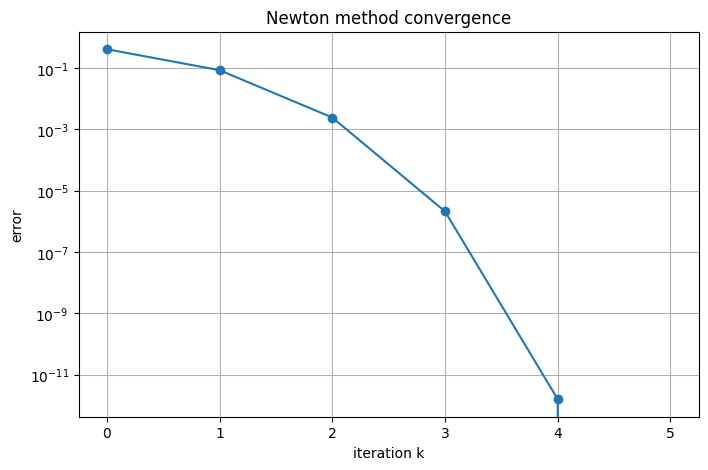

In [7]:
def newton_method(f, df, x0, tolerance=1e-10, max_iterations=100):
    x = x0
    
    approximations = [x]
    
    for k in range(max_iterations):
        fx = f(x)
        dfx = df(x)
        
        # Avoid division by zero
        if dfx == 0:
            print("Derivative is zero. Newton method stops.")
            return x, approximations
        
        # Newton formula
        x_new = x - fx / dfx
        
        approximations.append(x_new)
        
        # Stopping condition
        if abs(x_new - x) < tolerance:
            print("Newton method converged.")
            print("Number of iterations:", k + 1)
            return x_new, approximations
        
        x = x_new
    
    print("Newton method did not converge within the maximum number of iterations.")
    return approximations

#Example usage 

def f(x):
    return x**2 - 2

def df(x):
    return 2*x

# Error plotting 

root, approximations = newton_method(f, df, x0=1)
errors = [] 

print("Approximate root:", root)
print("f(root):", f(root))
exact_root = np.sqrt(2)

for x in approximations:
    error = abs(x - exact_root)
    errors.append(error)

plt.figure(figsize=(8, 5))
plt.semilogy(errors, marker="o")
plt.xlabel("iteration k")
plt.ylabel("error")
plt.title("Newton method convergence")
plt.grid(True)
plt.show()

## NEWTON'S METHOD FOR 2 EQUATIONS 

In [ ]:
import math 

# Define F(x, y)
# This returns the vector F = [f1, f2]

def F(x, y):
    f1 = x**2 + y**2 - 1
    f2 = x - y
    return [f1, f2]


# Define the Jacobian matrix J(x, y)
# J = [[df1/dx, df1/dy],
#      [df2/dx, df2/dy]]

def J(x, y):
    return [
        [2*x, 2*y],
        [1, -1]
    ] 

def inverse_2x2(A):
    a = A[0][0]
    b = A[0][1]
    c = A[1][0]
    d = A[1][1]
    
    determinant = a*d - b*c
    
    if determinant == 0:
        print("Matrix is not invertible.")
        return None
    
    A_inverse = [
        [d / determinant, -b / determinant],
        [-c / determinant, a / determinant]
    ]
    
    return A_inverse

def matrix_vector_multiply(A, v):
    result_1 = A[0][0] * v[0] + A[0][1] * v[1]
    result_2 = A[1][0] * v[0] + A[1][1] * v[1]
    
    return [result_1, result_2]


def newton_system_2x2(x0, y0, tolerance=1e-10, max_iterations=20):
    x = x0
    y = y0
    
    for k in range(max_iterations):
        # Compute F(x, y)
        F_value = F(x, y)
        
        # Compute J(x, y)
        J_value = J(x, y)
        
        # Compute inverse of J
        J_inverse = inverse_2x2(J_value)
        
        if J_inverse is None:
            print("Newton method stopped.")
            return x, y
        
        # Compute J^{-1} F
        correction = matrix_vector_multiply(J_inverse, F_value)
        
        # Newton update
        x_new = x - correction[0]
        y_new = y - correction[1]
        
        print("Iteration:", k + 1)
        print("x =", x_new)
        print("y =", y_new)
        print("F(x,y) =", F(x_new, y_new))
        print()
        
        # Stop if the change is very small
        change = math.sqrt((x_new - x)**2 + (y_new - y)**2)
        
        if change < tolerance:
            print("Newton method converged.")
            return x_new, y_new
        
        x = x_new
        y = y_new
    
    print("Maximum number of iterations reached.")
    return x, y

## NEWTON + HORNERS 
finds all polynomial roots 

In [ ]:
### computes polynomial value at a point 
def Horner_compute(coeff, point):
    result = coeff[0]

    for i in range(1, len(coeff)):
        result = result * point + coeff[i]

    return result

print(Horner_compute([2, -3, 4, -5], 1))

### computes coefficients of a polynomial after it was divided by 1 root 

def divide_poly(coeff, root):
    quotient = [coeff[0]] #the 1st coeff is equal to the 1st 

    for i in range(1, len(coeff) ):
        new_coeff = quotient[-1] * root + coeff[i] #multiply root by the already calculated coeff 
        quotient.append(new_coeff)
    
    return quotient


### computes 1 root of a polynomial

def Newton_poly(coeff, x0, tol, maxiter=10):
    d=len(coeff)-1
    derivative_coeff = [] #find derivative coeff to compute P'n
    for i in range(d):
        derivative_coeff.append(coeff[i] * (d - i)) #power-1*coeff
    i=0
    x=x0
    while abs(Horner_compute(coeff, x))>tol or i<maxiter:
        
        x=x-Horner_compute(coeff, x)/Horner_compute(derivative_coeff, x)
        i+=1
    return x


# calculates 1 root, divides polynomial by it, gets a new polynomial, calculates its root, etc returns a list of all roots 

def polynomial_roots(coeff, x0):
    roots=[]
    root=x0
    remainder=coeff
    while len(remainder)>1:
        root=Newton_poly(remainder, root, 10**(-12), maxiter=10**4) #finds root for ruture division
        roots.append(root)
        remainder= divide_poly(remainder, root) #finds coeffs of a new polynom 

    return roots

print(polynomial_roots([63/8, 0, -70/8, 0, 15/8, 0], 0.9))


## FIXED POINT ITERATION 

In [ ]:
def fixed_point_iteration(phi, x0, tol=1e-10, max_iter=100):
    x = x0
    
    for k in range(max_iter):
        x_new = phi(x)
        
        if abs(x_new - x) < tol:
            return x_new
        
        x = x_new
    
    return x

# LINEAR SYSTEMS 

## DIRECT METHODS 


### GAUSS ELLIMINATION 

In [ ]:
##Forward step: constructing upper triangular matrix and multiply the whole system by L^-1
# we get Ux = L^−1b 
def Gauss_elimination(A, b):
    n = len(b)
    x = [0] * n
    #for question 1b
    xreal1= [(0.5*10**-4)*(i-1)**2 for i in range(1, n+1)]

    #for question 1c 

    xreal2= [0 for i in range(n)]
    # Forward step
    for i in range(n):
        for j in range(i + 1, n):
            r = A[j][i] / A[i][i]

            for k in range(n):
                A[j][k] = A[j][k] - r * A[i][k]

            b[j] = b[j] - r * b[i]

    # Backward step
    for i in range(n - 1, -1, -1):
        x[i] = b[i]

        for j in range(i + 1, n):
            x[i] = x[i] - A[i][j] * x[j]

        x[i] = x[i] / A[i][i]
    
    maximum1 =max([abs(xreal1[i] - x[i]) for i in range(len(x))]) 
    maximum2 =max([abs(xreal2[i] - x[i]) for i in range(len(x))]) 
    return maximum2

# Example usage 
n = 101
#Matrix A 
A1 = [[0 for j in range(n)] for i in range(n)]
A1[0][0] = 1
A1[n-1][n-1]= 1


for i in range(1, n-1):
    A1[i][i-1] = 1
    A1[i][i] = -2 #diagonal 
    A1[i][i+1] = 1 #upper diagonal 

#Vector b 
b1 = [10**(-4)] * n
b1[0] = 0
b1[n-1] = 0.5

#print(Gauss_elimination(A1, b1))

### GAUSS PIVOTING 

In [ ]:

def Gauss_pivoting(A, b):
    n = len(b)
    x = [0] * n
    xreal2= [0 for i in range(n)]
    for i in range(n):
        pivot_row=i
        for j in range(i+1, n):
            if abs(A[j][i])> abs(A[pivot_row][i]):
                pivot_row= j
        A[i], A[pivot_row] = A[pivot_row], A[i]
        b[i], b[pivot_row] = b[pivot_row], b[i]     

    # Forward step
    
        for j in range(i + 1, n):
            r = A[j][i] / A[i][i]

            for k in range(n):
                A[j][k] = A[j][k] - r * A[i][k]

            b[j] = b[j] - r * b[i]

    # Backward step
    for i in range(n - 1, -1, -1):
        x[i] = b[i]

        for j in range(i + 1, n):
            x[i] = x[i] - A[i][j] * x[j]

        x[i] = x[i] / A[i][i]
    maximum2 =max([abs(xreal2[i] - x[i]) for i in range(len(x))]) 
    return maximum2

#example usage 
n=52 

A2=[[0 for j in range(n)] for i in range(n)]

for i in range(n):
    A2[i][i] = 1
    A2[i][n-1] = 1
    for j in range(i):
        A2[i][j]= -(i-j)

b2= [1.5]*n    
print(Gauss_pivoting(A2, b2))

### LOWER TRIANGULAR MATRICES 

In [4]:
def solve_lower_triangular(L, b):
    n = len(b)
    x = np.zeros(n)
    
    for i in range(n):
        s = b[i]
        
        for j in range(i):
            s = s - L[i][j] * x[j]
        
        x[i] = s / L[i][i]
    
    return x

L = np.array([
    [2, 0, 0],
    [3, 1, 0],
    [1, -2, 4]
], dtype=float)

b = np.array([4, 7, 3], dtype=float)

x = solve_lower_triangular(L, b)

print(x)


[2.   1.   0.75]


### UPPER TRIANGULAR MATRICES 

In [3]:
def solve_upper_triangular(U, b):
    n = len(b)
    x = np.zeros(n)
    
    for i in range(n - 1, -1, -1):
        s = b[i]
        
        for j in range(i + 1, n):
            s = s - U[i][j] * x[j]
        
        x[i] = s / U[i][i]
    
    return x

U = np.array([
    [2, 3, 1],
    [0, 1, -2],
    [0, 0, 4]
], dtype=float)

b = np.array([10, -3, 8], dtype=float)

x = solve_upper_triangular(U, b)

print(x)


[2.5 1.  2. ]


### QR DECOMPOSITION + GRAMM SCHMIDT 

In [ ]:
import numpy as np 
def QR_decomp(A):
    n=len(A)
    Q=[[0 for j in range(n)] for i in range(n)] #Q matrix only with 0 entries 
    for i in range(n): #Q matrix = Id
        Q[i][i] = 1
    
    Q = np.array(Q, dtype=float) #convert into a numpy array because matrix multiplication 
    R = np.array(A, dtype=float)

    sdot = 0

    for k in range(n-1):
        r_k = R[k:n, k] # from row k to row n-1 take column kth
        norm_r = np.linalg.norm(r_k)
        sdot = 1 / (norm_r * (r_k[0] + norm_r))
        
        #Constructing a Householder matrix 
        H_k = np.eye(n - k) - sdot * np.outer(r_k, r_k) # ID- multiplication H*H^T

        # update R[k:n, k:n] = H_k R[k:n, k:n]
        R[k:n, k:n] = np.matmul(H_k, R[k:n, k:n]) # matrix multiplication 

        # update Q[:, k:n] = Q[:, k:n] H_k
        Q[:, k:n] = np.matmul(Q[:, k:n], H_k)

    return Q, R

### QR DECOMPOSITION + HOUSEHOLDER TRANSFORMATION 

In [ ]:
import numpy as np


def householder_qr(A):
    A = A.astype(float)
    
    m, n = A.shape
    
    Q = np.eye(m)
    R = A.copy()
    
    for k in range(min(m, n)):
        # Take the part of column k below and including the diagonal
        x = R[k:, k]
        
        norm_x = np.linalg.norm(x)
        
        if norm_x == 0:
            continue
        
        # Choose sign for numerical stability
        if x[0] >= 0:
            sign = 1
        else:
            sign = -1
        
        # e1 = (1, 0, 0, ...)
        e1 = np.zeros(len(x))
        e1[0] = 1
    
        # Householder vector
        v = x + sign * norm_x * e1
        
        # Normalize v
        v = v / np.linalg.norm(v)
        
        # Apply Householder reflection to R
        R[k:, k:] = R[k:, k:] - 2 * np.outer(v, v @ R[k:, k:])
        
        # Accumulate Q
        Q[:, k:] = Q[:, k:] - 2 * np.outer(Q[:, k:] @ v, v)
    
    return Q, R

Identity matrix 

In [ ]:
import numpy as np 
np.eye(n)  


Matrix * Transpose matrix

In [ ]:
A= [ [1, 0],
    [ 0, 1]]
np.outer(A, A)

### THOMAS ALGORITHM 

Diagonal decomposition:

In [ ]:
import numpy as np


def split_tridiagonal(A):
    A = np.array(A, dtype=float)
    
    n = A.shape[0]
    
    # Create arrays
    lower = np.zeros(n)   # a
    main = np.zeros(n)    # c
    upper = np.zeros(n)   # b
    
    for i in range(n):
        # Main diagonal
        main[i] = A[i, i]
        
        # Lower diagonal
        if i > 0:
            lower[i] = A[i, i - 1]
        
        # Upper diagonal
        if i < n - 1:
            upper[i] = A[i, i + 1]
    
    return lower, main, upper

THOMAS CONDITIONS ( well defined, stable )

In [22]:
import numpy as np


def check_condition_1(b, tol=1e-14):
    """
    Condition 1:
    b_i != 0 for i = 1,...,n-1

    In Python indexing:
    b[0], ..., b[n-2] must be non-zero.
    We ignore b[n-1] because b_n = 0 by convention.
    """
    n = len(b)

    for i in range(n - 1):
        if abs(b[i]) < tol:
            print("Condition 1 failed at i =", i + 1)
            print("b_i =", b[i])
            return False

    print("Condition 1 satisfied: all upper diagonal entries b_1,...,b_{n-1} are non-zero.")
    return True

def check_condition_2(a, c, b, tol=1e-14):
    """
    Condition 2:
    |c_i| >= |a_i| + |b_i| for all i = 1,...,n

    This means the matrix is diagonally dominant.
    """
    n = len(c)

    for i in range(n):
        left = abs(c[i])
        right = abs(a[i]) + abs(b[i])

        if left + tol < right:
            print("Condition 2 failed at row i =", i + 1)
            print("|c_i| =", left)
            print("|a_i| + |b_i| =", right)
            return False

    print("Condition 2 satisfied: matrix is non-strictly diagonally dominant.")
    return True

def check_condition_3(a, c, b, tol=1e-14):
    """
    Condition 3:
    There exists at least one row k such that

    |c_k| > |a_k| + |b_k|

    So at least one row must be strictly diagonally dominant.
    """
    n = len(c)

    for i in range(n):
        left = abs(c[i])
        right = abs(a[i]) + abs(b[i])

        if left > right + tol:
            print("Condition 3 satisfied at row k =", i + 1)
            print("|c_k| =", left)
            print("|a_k| + |b_k| =", right)
            return True

    print("Condition 3 failed: no row is strictly diagonally dominant.")
    return False



def check_thomas_usability(a, c, b, tol=1e-14):
    """
    Checks all 3 sufficient conditions from the theorem.
    """

    cond1 = check_condition_1(b, tol)
    cond2 = check_condition_2(a, c, b, tol)
    cond3 = check_condition_3(a, c, b, tol)

    if cond1 and cond2 and cond3:
        print("\nThomas algorithm is usable according to the theorem.")
        return True
    else:
        print("\nThe theorem does not guarantee that Thomas algorithm is usable.")
        return False
    

a = np.array([0, -1, -1, -1], dtype=float)
c = np.array([2, 2, 2, 2], dtype=float)
b = np.array([-1, -1, -1, 0], dtype=float)

check_thomas_usability(a, c, b)

Condition 1 satisfied: all upper diagonal entries b_1,...,b_{n-1} are non-zero.
Condition 2 satisfied: matrix is non-strictly diagonally dominant.
Condition 3 satisfied at row k = 1
|c_k| = 2.0
|a_k| + |b_k| = 1.0

Thomas algorithm is usable according to the theorem.


True

In [9]:
import numpy as np


def thomas_algorithm(a, c, b, f): #a b and c are the 3 diagonals 
    n = len(f)
    
    # Create arrays for alpha, beta, and solution x
    alpha = np.zeros(n)
    beta = np.zeros(n)
    x = np.zeros(n)
    
    # Initial values from the script
    alpha[0] = 0
    beta[0] = 0
    
    # Forward sweep
    for i in range(n - 1):
        denominator = c[i] + a[i] * alpha[i]
        
        alpha[i + 1] = -b[i] / denominator
        beta[i + 1] = (f[i] - a[i] * beta[i]) / denominator
    
    # Backward sweep: compute x_n first
    denominator = c[n - 1] + a[n - 1] * alpha[n - 1]
    x[n - 1] = (f[n - 1] - a[n - 1] * beta[n - 1]) / denominator
    
    # Then compute x_{n-1}, ..., x_1
    for i in range(n - 2, -1, -1):
        x[i] = alpha[i + 1] * x[i + 1] + beta[i + 1]
    
    return x


#Example usage 
a = np.array([0, -1, -1], dtype=float)   # lower diagonal
c = np.array([2, 2, 2], dtype=float)     # main diagonal
b = np.array([-1, -1, 0], dtype=float)   # upper diagonal
f = np.array([0, 0, 4], dtype=float)     # right-hand side

x = thomas_algorithm(a, c, b, f)

print(x)

[1. 2. 3.]


THOMAS WITH DISCRITISATION FORMULA 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def solve_poisson_with_thomas(n):
    """
    Solve -u'' = pi^2 sin(pi x), u(0)=u(1)=0
    using n interior grid points.
    """

    h = 1 / (n + 1) #can be anything like (b-a)

    # interior grid points: x_1, ..., x_n
    x_grid = np.linspace(h, 1 - h, n)

    # diagonals for matrix A = 1/h^2 * tridiag(-1, 2, -1).   #The diagonals we found 
    a = (-1 / h**2) * np.ones(n)   # lower diagonal
    c = (2 / h**2) * np.ones(n)    # main diagonal
    b = (-1 / h**2) * np.ones(n)   # upper diagonal

    # The Interval 
    a[0] = 0
    b[-1] = 0

    # right-hand side
    f = (np.pi**2) * np.sin(np.pi * x_grid)

    # numerical solution
    u_num = thomas_algorithm(a, c, b, f) #use function above 

    # exact solution
    u_exact = np.sin(np.pi * x_grid) # our function 

    # max error
    error = np.max(np.abs(u_exact - u_num))

    return x_grid, u_num, u_exact, error, h

n_list = [10, 20, 40, 80, 160, 320]

errors = []
h_values = []

for n in n_list:
    x_grid, u_num, u_exact, error, h = solve_poisson_with_thomas(n)

    errors.append(error)
    h_values.append(h)

    print("n =", n, "h =", h, "max error =", error)

## Plotting numerical solution for 1 n 
n = 40
x_grid, u_num, u_exact, error, h = solve_poisson_with_thomas(n)

plt.figure(figsize=(8, 5))
plt.plot(x_grid, u_exact, label="exact solution")
plt.plot(x_grid, u_num, "o", label="Thomas solution")
plt.xlabel("x")
plt.ylabel("u")
plt.title("Numerical solution using Thomas algorithm")
plt.legend()
plt.grid(True)
plt.show()

## Plotting the error 
errors = np.array(errors)
h_values = np.array(h_values)

plt.figure(figsize=(8, 5))
plt.loglog(h_values, errors, "o-", label="max error")
plt.loglog(h_values, h_values**2, "--", label=r"reference $h^2$")
plt.xlabel("h")
plt.ylabel("max error")
plt.title("Error convergence of finite difference + Thomas algorithm")
plt.legend()
plt.grid(True)
plt.show()


## Convergence rate 
orders = []

for i in range(len(errors) - 1):
    order = np.log(errors[i + 1] / errors[i]) / np.log(h_values[i + 1] / h_values[i])
    orders.append(order)

print("Observed convergence orders:")
for i, order in enumerate(orders):
    print(f"from n={n_list[i]} to n={n_list[i+1]}: order = {order}")

### THOMAS FOR BLOCK TRIDIAGONAL MATRICES 

In [ ]:
import numpy as np


def block_thomas_algorithm(A, C, B, f):
    n = len(f)              # number of block rows
    m = len(f[0])           # size of each block vector
    
    alpha = [np.zeros((m, m)) for _ in range(n)]
    beta = [np.zeros(m) for _ in range(n)]
    x = [np.zeros(m) for _ in range(n)]
    
    # alpha[0] = 0 matrix, beta[0] = 0 vector already
    
    # Forward sweep
    for i in range(n - 1):
        M = C[i] - A[i] @ alpha[i] #  @ dot product of 2 vectors, equivalent to np.dot and np.matmul
        
        # alpha_{i+1} = M^{-1} B_i
        alpha[i + 1] = np.linalg.solve(M, B[i]) #COMPUTES THE INVERSE 
        
        # beta_{i+1} = M^{-1} (f_i - A_i beta_i)
        beta[i + 1] = np.linalg.solve(M, f[i] - A[i] @ beta[i])
    
    # Backward sweep: compute x_n first
    M = C[n - 1] - A[n - 1] @ alpha[n - 1]
    x[n - 1] = np.linalg.solve(M, f[n - 1] - A[n - 1] @ beta[n - 1])
    
    # Then compute x_{n-1}, ..., x_1
    for i in range(n - 2, -1, -1):
        x[i] = alpha[i + 1] @ x[i + 1] + beta[i + 1]
    
    return x

#EXAMPLE USAGE 

# Number of block rows: n = 3
# Block size: m = 2

zero = np.zeros((2, 2))

A = [
    zero,
    np.array([[1, 0],
              [0, 1]], dtype=float),
    np.array([[1, 0],
              [0, 1]], dtype=float)
]

C = [
    np.array([[4, 1],
              [1, 3]], dtype=float),
    np.array([[4, 1],
              [1, 3]], dtype=float),
    np.array([[4, 1],
              [1, 3]], dtype=float)
]

B = [
    np.array([[1, 0],
              [0, 1]], dtype=float),
    np.array([[1, 0],
              [0, 1]], dtype=float),
    zero
]

f = [
    np.array([1, 2], dtype=float),
    np.array([2, 1], dtype=float),
    np.array([3, 4], dtype=float)
]

x = block_thomas_algorithm(A, C, B, f)

for i in range(len(x)):
    print("x_" + str(i + 1), "=", x[i])

## ITERATIVE METHODS 

Classical decomposition of A= D-E-F 

D-diagonal, E-upper, F-lower 

In [8]:
import numpy as np


def decompose_D_E_F(A):
    A = np.array(A, dtype=float)
    
    n = A.shape[0]
    
    D = np.zeros_like(A)
    E = np.zeros_like(A)
    F = np.zeros_like(A)
    
    for i in range(n):
        for j in range(n):
            
            if i == j:
                # diagonal part
                D[i, j] = A[i, j]
            
            elif i > j:
                # strictly lower part
                # because A = D - E - F, we store E = - lower part of A
                E[i, j] = -A[i, j]
            
            elif i < j:
                # strictly upper part
                # because A = D - E - F, we store F = - upper part of A
                F[i, j] = -A[i, j]
    
    return D, E, F

### Example usage 
A = np.array([
    [3, 2, 0],
    [2, 3, 0],
    [0, 0, 1]
], dtype=float)

D, E, F = decompose_D_E_F(A)

print("D =")
print(D)

print("E =")
print(E)

print("F =")
print(F)

D =
[[3. 0. 0.]
 [0. 3. 0.]
 [0. 0. 1.]]
E =
[[ 0.  0.  0.]
 [-2.  0.  0.]
 [-0. -0.  0.]]
F =
[[ 0. -2. -0.]
 [ 0.  0. -0.]
 [ 0.  0.  0.]]


### RICHARDSON ITERATION 

In [ ]:
import numpy as np

def richardson_iteration(A, b, w, x0, tol=1e-10, max_iter=100):
    x = x0.copy()
    
    for k in range(max_iter):
        # Compute residual r = b - A x
        residual = b - A @ x
        
        # Richardson update
        x_new = x + w * residual
        
        print("Iteration:", k + 1) # prints every iteration result 
        print("x =", x_new)
        
        # Stop if residual is small enough
        if np.linalg.norm(residual) < tol:
            print("Converged.")
            return x_new
        
        x = x_new
    
    print("Maximum number of iterations reached.")
    return x

# usage example 

A = np.array([
    [4, 1],
    [1, 3]
], dtype=float)

b = np.array([1, 2], dtype=float)

x0 = np.array([0, 0], dtype=float)

omega = 0.25

x = richardson_iteration(A, b, omega, x0)

print("Approximate solution:")
print(x)

### JACOBI ITERATION 

In [ ]:
def jacobi_method(A, b, x0, tol=1e-10, max_iter=100):
    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float)
    x = np.array(x0, dtype=float)
    
    D, E, F = decompose_D_E_F(A)
    
    for k in range(max_iter):
        rhs = b + (E + F) @ x
        
        # Since D is diagonal, this is easy:
        x_new = np.zeros_like(x)
        for i in range(len(x)):
            x_new[i] = rhs[i] / D[i, i]
        
        residual = np.linalg.norm(A @ x_new - b)
        
        print("Jacobi iteration", k + 1, "x =", x_new, "residual =", residual)
        
        if residual < tol:
            return x_new
        
        x = x_new
    
    return x

### GAUSS - SEIDEL ITERATION 

In [ ]:
def gauss_seidel_method(A, b, x0, tol=1e-10, max_iter=100):
    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float)
    x = np.array(x0, dtype=float)
    
    D, E, F = decompose_D_E_F(A)
    
    for k in range(max_iter):
        left_matrix = D - E
        rhs = b + F @ x
        
        x_new = np.linalg.solve(left_matrix, rhs)
        
        residual = np.linalg.norm(A @ x_new - b)
        
        print("Gauss-Seidel iteration", k + 1, "x =", x_new, "residual =", residual)
        
        if residual < tol:
            return x_new
        
        x = x_new
    
    return x

### SOR ITERATION 

In [ ]:
def sor_method(A, b, x0, omega, tol=1e-10, max_iter=100):
    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float)
    x = np.array(x0, dtype=float)
    
    D, E, F = decompose_D_E_F(A)
    
    for k in range(max_iter):
        left_matrix = D - omega * E
        rhs = ((1 - omega) * D + omega * F) @ x + omega * b
        
        x_new = np.linalg.solve(left_matrix, rhs)
        
        residual = np.linalg.norm(A @ x_new - b)
        
        print("SOR iteration", k + 1, "x =", x_new, "residual =", residual)
        
        if residual < tol:
            return x_new
        
        x = x_new
    
    return x